# Walmart — pistes d'amelioration hors perimetre

> **Ce notebook n'est pas le livrable.** Le livrable est `01-Walmart_sales.ipynb`, qui respecte
> strictement l'enonce : regle des 3-sigma, `Store` en variable categorielle encodee en one-hot,
> et perimetre limite aux modeles lineaires (`LinearRegression`, `Ridge`, `Lasso`).
>
> On explore ici quatre pistes qui **s'ecartent de cet enonce**, uniquement pour **chiffrer ce
> que le livrable laisse sur la table**. Chacune est mesuree avec le meme protocole et sur le
> meme decoupage que le livrable, pour que les chiffres soient directement comparables.

| Piste | En quoi elle s'ecarte de l'enonce |
|---|---|
| **A1** — transformation `log1p` de la target | L'enonce ne prevoit aucune transformation de la target |
| **A2** — encodage par cible des magasins | L'enonce designe `Store` comme variable categorielle |
| **A3** — modeles non lineaires | L'enonce limite le perimetre a la regression lineaire |
| **A4** — `ElasticNet` | L'enonce dit « Lasso ou Ridge » |

**Reference a battre** : `Ridge(alpha=0.01)`, R2 = 0.873 +/- 0.162 en validation croisee.

## Mise en place

Meme donnees, meme decoupage, meme protocole que le livrable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

from src import walmart as w
from src import improvements as imp

# Meme chaine que le livrable
df = w.load_raw('Walmart_Store_sales.csv')
df_clean = w.clean(df)

X = df_clean.drop(w.TARGET, axis=1)
y = df_clean[w.TARGET]

X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, y_train, _ = w.apply_3sigma(X_train_full, y_train_full,
                                     w.fit_3sigma_bounds(X_train_full))

CV = w.make_cv(n_splits=5, n_repeats=10, random_state=42)

print(f"Train : {len(X_train)} lignes   Hold-out : {len(X_holdout)} lignes")
print(f"Protocole : {CV.get_n_splits()} folds (identique au livrable)")

Train : 90 lignes   Hold-out : 24 lignes
Protocole : 50 folds (identique au livrable)


In [2]:
results = {}


def evaluer(nom, make_model, pipeline_factory=w.build_pipeline):
    """Evalue une piste avec le protocole du livrable et l'enregistre."""
    res = w.cv_evaluate(make_model, X_train, y_train, cv=CV, pipeline_factory=pipeline_factory)
    results[nom] = res
    w.print_cv(nom, res)
    return res


# Reference : le modele retenu dans le livrable
evaluer('Reference : Ridge(0.01) + dummies', lambda: Ridge(alpha=0.01))

=== Reference : Ridge(0.01) + dummies ===
  R2   CV : 0.8729 +/- 0.1617   (min -0.157 / max 0.958 sur 50 folds)
  RMSE CV : 218,155 $ +/- 81,731 $
  MAE  CV : 163,289 $
  R2 train : 0.9682  |  R2 ajuste train : 0.9466
  Ecart train/validation : 0.0953



{'r2_mean': 0.8729048717630987,
 'r2_std': 0.16172188101899548,
 'r2_min': -0.15703524330396457,
 'r2_max': 0.9579304726603977,
 'rmse_mean': 218155.251940538,
 'rmse_std': 81730.78805463009,
 'mae_mean': 163289.2537675728,
 'r2_train_mean': 0.9682262657985574,
 'r2_adj_train': 0.9466424717083807,
 'r2_folds': array([ 0.9040395 ,  0.90075433,  0.93159234,  0.93525672,  0.90274134,
         0.80659451,  0.85692937,  0.93375563,  0.95635562,  0.95793047,
         0.94880062,  0.91741513,  0.91395014,  0.85572961,  0.90786939,
         0.92770072,  0.88178347,  0.92017771,  0.90020899,  0.93605465,
         0.78220403,  0.95034189,  0.92905334,  0.92166525,  0.94857978,
         0.88774553,  0.85912684,  0.94716795, -0.15703524,  0.92389257,
         0.93862498,  0.89977776,  0.83580454,  0.9107738 ,  0.93825359,
         0.90061921,  0.79312701,  0.91615276,  0.94916231,  0.72260101,
         0.79482338,  0.88280916,  0.92803283,  0.9227473 ,  0.94975514,
         0.89017285,  0.88866464

## A1 — Transformation `log1p` de la target

Les ventes s'etalent de 268 929 $ a 2 771 397 $, soit un facteur 10. Une regression sur
`log1p(y)` stabilise la variance et rend l'echelle d'alpha naturelle.

`TransformedTargetRegressor` applique `log1p` avant l'apprentissage et `expm1` sur les
predictions : **les metriques restent exprimees en dollars**, donc comparables au livrable.

In [3]:
evaluer('A1 : log1p(y) + Ridge(0.01)', lambda: imp.log_target(Ridge(alpha=1.0)))

# Sur la target log-transformee, l'echelle d'alpha change completement : on la re-cherche.
grid_log = GridSearchCV(
    w.build_pipeline(imp.log_target(Ridge())),
    {'model__regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
).fit(X_train, y_train)

alpha_log = grid_log.best_params_['model__regressor__alpha']
print(f"Meilleur alpha sur target log-transformee : {alpha_log}")
evaluer(f'A1 : log1p(y) + Ridge({alpha_log}) optimise',
        lambda: imp.log_target(Ridge(alpha=alpha_log)))

=== A1 : log1p(y) + Ridge(0.01) ===
  R2   CV : 0.7742 +/- 0.1244   (min 0.239 / max 0.961 sur 50 folds)
  RMSE CV : 307,837 $ +/- 87,596 $
  MAE  CV : 218,329 $
  R2 train : 0.8974  |  R2 ajuste train : 0.8276
  Ecart train/validation : 0.1232



Meilleur alpha sur target log-transformee : 0.001


=== A1 : log1p(y) + Ridge(0.001) optimise ===
  R2   CV : 0.8603 +/- 0.3538   (min -1.521 / max 0.975 sur 50 folds)
  RMSE CV : 202,978 $ +/- 122,476 $
  MAE  CV : 143,650 $
  R2 train : 0.9741  |  R2 ajuste train : 0.9566
  Ecart train/validation : 0.1138



{'r2_mean': 0.8603136817908542,
 'r2_std': 0.353760253326227,
 'r2_min': -1.52108788469473,
 'r2_max': 0.9746132748598084,
 'rmse_mean': 202978.38411124184,
 'rmse_std': 122476.44651120201,
 'mae_mean': 143649.6327580306,
 'r2_train_mean': 0.97413586072196,
 'r2_adj_train': 0.9565697969910499,
 'r2_folds': array([ 0.92758556,  0.90051541,  0.95751727,  0.9485595 ,  0.9272482 ,
         0.86741954,  0.86979007,  0.94446947,  0.95593596,  0.97461327,
         0.95588223,  0.94281693,  0.94751637,  0.87293841,  0.91648392,
         0.92318878,  0.90212905,  0.93811152,  0.93757202,  0.96099245,
         0.87892699,  0.97107385,  0.95169544,  0.90358894,  0.95227063,
         0.8996198 ,  0.89879506,  0.96099915, -1.52108788,  0.93050785,
         0.95477347,  0.90119666,  0.91096702,  0.89711212,  0.95234454,
         0.89407862,  0.81801217,  0.94017154,  0.9597303 ,  0.58140373,
         0.91773978,  0.94666341,  0.94354427,  0.9231861 ,  0.96993544,
         0.93093899,  0.92079468,  0

## A2 — Encodage par cible des magasins

Les 20 dummies de magasin consomment l'essentiel du budget de parametres : 29 features pour
90 lignes d'entrainement. L'encodage par cible les ramene a **une seule colonne numerique**,
la moyenne lissee des ventes du magasin.

Il resout aussi le probleme des magasins 11 et 12, presents dans le hold-out mais absents du
train : au lieu d'un vecteur nul, ils recoivent la moyenne generale.

Le lissage bayesien evite qu'un magasin vu deux fois impose sa moyenne brute. La limite connue
est que l'encodage d'une ligne utilise la cible de cette ligne — le lissage attenue cette fuite
sans la supprimer.

In [4]:
n_dummies = w.build_pipeline(Ridge())[:-1].fit(X_train, y_train).transform(X_train).shape[1]
n_te = imp.build_pipeline_target_encoded(Ridge())[:-1].fit(X_train, y_train).transform(X_train).shape[1]

print(f"Features avec dummies        : {n_dummies}  (ratio p/n = {n_dummies / len(X_train):.2f})")
print(f"Features avec target encoding: {n_te}  (ratio p/n = {n_te / len(X_train):.2f})")
print()

evaluer('A2 : Ridge(0.01) + target encoding', lambda: Ridge(alpha=0.01),
        pipeline_factory=imp.build_pipeline_target_encoded)

Features avec dummies        : 29  (ratio p/n = 0.32)
Features avec target encoding: 12  (ratio p/n = 0.13)



=== A2 : Ridge(0.01) + target encoding ===
  R2   CV : 0.8119 +/- 0.1132   (min 0.285 / max 0.967 sur 50 folds)
  RMSE CV : 277,763 $ +/- 74,948 $
  MAE  CV : 213,588 $
  R2 train : 0.9249  |  R2 ajuste train : 0.9096
  Ecart train/validation : 0.1130



{'r2_mean': 0.8118711048144438,
 'r2_std': 0.11319797767729238,
 'r2_min': 0.2846975222173357,
 'r2_max': 0.9671603850592497,
 'rmse_mean': 277762.80047865515,
 'rmse_std': 74948.4093351154,
 'mae_mean': 213588.31978312184,
 'r2_train_mean': 0.9249157039211299,
 'r2_adj_train': 0.9096443216678003,
 'r2_folds': array([0.93692522, 0.65817797, 0.78780812, 0.92317916, 0.76472228,
        0.79248528, 0.65968174, 0.81958684, 0.92447441, 0.96716039,
        0.80602466, 0.85270005, 0.62566322, 0.80565633, 0.84724254,
        0.8822497 , 0.86772868, 0.83531006, 0.64911547, 0.85322374,
        0.65170137, 0.92178624, 0.94404091, 0.86986872, 0.89918493,
        0.87499968, 0.64397043, 0.89803613, 0.28469752, 0.87808091,
        0.72353803, 0.83685672, 0.7681335 , 0.89113288, 0.93358081,
        0.79575788, 0.85685065, 0.73493567, 0.89093439, 0.81743986,
        0.71823192, 0.80717293, 0.83584204, 0.82423869, 0.86312707,
        0.86726369, 0.81814634, 0.83874946, 0.79933916, 0.84680087]),
 'n_fol

In [5]:
# Verification : un magasin inconnu est-il gere proprement ?
pipe_te = imp.build_pipeline_target_encoded(Ridge(alpha=0.01)).fit(X_train, y_train)

inconnus = sorted(set(X_holdout['Store']) - set(X_train['Store']))
print(f"Magasins du hold-out absents du train : {inconnus}")

if inconnus:
    masque = X_holdout['Store'].isin(inconnus)
    pipe_ohe = w.build_pipeline(Ridge(alpha=0.01)).fit(X_train, y_train)
    err_ohe = np.abs(y_holdout[masque] - pipe_ohe.predict(X_holdout[masque])).mean()
    err_te = np.abs(y_holdout[masque] - pipe_te.predict(X_holdout[masque])).mean()
    print(f"\nErreur absolue moyenne sur ces {int(masque.sum())} ligne(s) :")
    print(f"  dummies         : {err_ohe:,.0f} $")
    print(f"  target encoding : {err_te:,.0f} $")

Magasins du hold-out absents du train : ['11', '12']

Erreur absolue moyenne sur ces 2 ligne(s) :
  dummies         : 660,819 $
  target encoding : 224,730 $


## A3 — Modeles non lineaires en reference

Les arbres capturent l'effet magasin sans dummies et la saisonnalite sans encodage cyclique.
Ils servent ici de **point de comparaison** : ils chiffrent ce qu'un modele lineaire ne peut
pas atteindre sur ces donnees.

In [6]:
evaluer('A3 : RandomForest', lambda: RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1))

evaluer('A3 : GradientBoosting', lambda: GradientBoostingRegressor(random_state=42))

=== A3 : RandomForest ===
  R2   CV : 0.6574 +/- 0.1240   (min 0.386 / max 0.839 sur 50 folds)
  RMSE CV : 382,933 $ +/- 68,730 $
  MAE  CV : 295,713 $
  R2 train : 0.9543  |  R2 ajuste train : 0.9232
  Ecart train/validation : 0.2969



=== A3 : GradientBoosting ===
  R2   CV : 0.7927 +/- 0.1011   (min 0.484 / max 0.930 sur 50 folds)
  RMSE CV : 293,019 $ +/- 67,188 $
  MAE  CV : 202,234 $
  R2 train : 0.9960  |  R2 ajuste train : 0.9932
  Ecart train/validation : 0.2033



{'r2_mean': 0.7927221682443094,
 'r2_std': 0.10105290164848106,
 'r2_min': 0.4838857298339748,
 'r2_max': 0.9304280546789441,
 'rmse_mean': 293018.9513483958,
 'rmse_std': 67188.3710443114,
 'mae_mean': 202234.1378122812,
 'r2_train_mean': 0.9959807723699664,
 'r2_adj_train': 0.9932450286822858,
 'r2_folds': array([0.90863765, 0.79063303, 0.71603028, 0.85666802, 0.73054313,
        0.78527956, 0.62395717, 0.76852841, 0.90496469, 0.91382839,
        0.60334357, 0.92255647, 0.76380635, 0.73189815, 0.87141571,
        0.92605495, 0.72107147, 0.81335663, 0.81907535, 0.80930959,
        0.7490799 , 0.812581  , 0.90362221, 0.75810056, 0.90403882,
        0.85097515, 0.82175844, 0.76895572, 0.57492361, 0.78497681,
        0.89916725, 0.85976523, 0.79722689, 0.58318598, 0.87357345,
        0.81987106, 0.82636289, 0.77686107, 0.79948008, 0.65997633,
        0.48388573, 0.80868566, 0.92817087, 0.91349163, 0.7753993 ,
        0.77977737, 0.69187327, 0.93042805, 0.68129806, 0.83765745]),
 'n_folds

## A4 — ElasticNet

Avec 20 dummies fortement correlees entre elles, une penalite mixte L1 + L2 est le choix
theoriquement adapte : le L1 selectionne, le L2 repartit le poids entre features correlees.

Comme pour le Lasso du livrable, la grille d'alpha doit etre calee sur l'echelle de la target
(~1e6) et `max_iter` releve, sans quoi l'optimisation ne converge pas.

In [7]:
grid_en = GridSearchCV(
    w.build_pipeline(ElasticNet(max_iter=1_000_000, tol=1e-4)),
    {'model__alpha': [1, 10, 100, 1000, 10000],
     'model__l1_ratio': [0.1, 0.5, 0.9]},
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
).fit(X_train, y_train)

best = grid_en.best_params_
print(f"Meilleurs parametres : alpha={best['model__alpha']}, l1_ratio={best['model__l1_ratio']}")
print(f"RMSE de validation   : {-grid_en.best_score_:,.0f} $")
print()

evaluer(f"A4 : ElasticNet(alpha={best['model__alpha']}, l1={best['model__l1_ratio']})",
        lambda: ElasticNet(alpha=best['model__alpha'], l1_ratio=best['model__l1_ratio'],
                           max_iter=1_000_000, tol=1e-4))

Meilleurs parametres : alpha=1, l1_ratio=0.9
RMSE de validation   : 468,980 $



=== A4 : ElasticNet(alpha=1, l1=0.9) ===
  R2   CV : 0.5026 +/- 0.1045   (min 0.303 / max 0.724 sur 50 folds)
  RMSE CV : 467,201 $ +/- 55,301 $
  MAE  CV : 394,115 $
  R2 train : 0.6768  |  R2 ajuste train : 0.4571
  Ecart train/validation : 0.1742



{'r2_mean': 0.5026247353407043,
 'r2_std': 0.10446689162576808,
 'r2_min': 0.30282775841736875,
 'r2_max': 0.7238285926692714,
 'rmse_mean': 467201.33984105865,
 'rmse_std': 55301.35504828526,
 'mae_mean': 394114.5270001202,
 'r2_train_mean': 0.6767952456751166,
 'r2_adj_train': 0.45708047230057214,
 'r2_folds': array([0.62199862, 0.33472681, 0.57358647, 0.53887413, 0.41339336,
        0.50562569, 0.36232032, 0.54644271, 0.45738957, 0.63040019,
        0.52572835, 0.57049151, 0.42479668, 0.42991958, 0.4365677 ,
        0.57622962, 0.40741375, 0.5445031 , 0.50002356, 0.50692319,
        0.3493957 , 0.64368903, 0.51839888, 0.46390955, 0.63024856,
        0.58952131, 0.5223352 , 0.4269595 , 0.40973476, 0.43373566,
        0.48580998, 0.62969227, 0.38756681, 0.32940806, 0.67231189,
        0.56654919, 0.30282776, 0.53710092, 0.49733139, 0.6562283 ,
        0.30906344, 0.45129962, 0.62325247, 0.58531083, 0.3811461 ,
        0.4866223 , 0.53771021, 0.67270836, 0.40018521, 0.72382859]),
 'n_f

## A1 + A2 combinees

Les deux pistes agissent sur des leviers independants : l'une sur l'echelle de la target,
l'autre sur la dimension. Les cumuler a du sens.

In [8]:
evaluer('A1+A2 : log1p(y) + target encoding',
        lambda: imp.log_target(Ridge(alpha=alpha_log)),
        pipeline_factory=imp.build_pipeline_target_encoded)

=== A1+A2 : log1p(y) + target encoding ===
  R2   CV : 0.6576 +/- 0.2012   (min -0.091 / max 0.964 sur 50 folds)
  RMSE CV : 373,085 $ +/- 107,749 $
  MAE  CV : 276,843 $
  R2 train : 0.8199  |  R2 ajuste train : 0.7833
  Ecart train/validation : 0.1624



{'r2_mean': 0.6575644923214449,
 'r2_std': 0.2011788132282095,
 'r2_min': -0.0910173673536554,
 'r2_max': 0.9637016985492465,
 'rmse_mean': 373084.858171997,
 'rmse_std': 107749.49510318712,
 'mae_mean': 276843.14835314266,
 'r2_train_mean': 0.819929112633766,
 'r2_adj_train': 0.7833045253728375,
 'r2_folds': array([ 0.56526959,  0.43808471,  0.69770391,  0.9637017 ,  0.53163287,
         0.44159938, -0.09101737,  0.77363842,  0.88359863,  0.93136718,
         0.77385871,  0.82710857,  0.40448784,  0.5834436 ,  0.70659664,
         0.74639995,  0.88806521,  0.72795152,  0.63516069,  0.2051398 ,
         0.33095249,  0.8485988 ,  0.8881688 ,  0.78220528,  0.80246853,
         0.57031622,  0.50050532,  0.73439148,  0.48135853,  0.83524477,
         0.5437395 ,  0.71564849,  0.65467172,  0.73661989,  0.7985115 ,
         0.60762077,  0.68820614,  0.67308196,  0.8172491 ,  0.75719362,
         0.20078661,  0.80033903,  0.59910217,  0.75482607,  0.70405274,
         0.79581197,  0.51169591,

## Comparaison de toutes les pistes

In [9]:
comparaison = pd.DataFrame([
    {
        'Piste': nom,
        'R2 CV': s['r2_mean'],
        'Std R2': s['r2_std'],
        'R2 min': s['r2_min'],
        'RMSE CV': s['rmse_mean'],
        'R2 train': s['r2_train_mean'],
    }
    for nom, s in results.items()
]).sort_values('R2 CV', ascending=False).reset_index(drop=True)

ref = comparaison[comparaison['Piste'].str.startswith('Reference')].iloc[0]
comparaison['Gain R2'] = comparaison['R2 CV'] - ref['R2 CV']

print("=== TOUTES LES PISTES (validation croisee, 50 folds) ===\n")
print(comparaison.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

=== TOUTES LES PISTES (validation croisee, 50 folds) ===

                                Piste  R2 CV  Std R2  R2 min      RMSE CV  R2 train  Gain R2
    Reference : Ridge(0.01) + dummies 0.8729  0.1617 -0.1570 218,155.2519    0.9682   0.0000
A1 : log1p(y) + Ridge(0.001) optimise 0.8603  0.3538 -1.5211 202,978.3841    0.9741  -0.0126
   A2 : Ridge(0.01) + target encoding 0.8119  0.1132  0.2847 277,762.8005    0.9249  -0.0610
                A3 : GradientBoosting 0.7927  0.1011  0.4839 293,018.9513    0.9960  -0.0802
          A1 : log1p(y) + Ridge(0.01) 0.7742  0.1244  0.2394 307,837.2711    0.8974  -0.0987
   A1+A2 : log1p(y) + target encoding 0.6576  0.2012 -0.0910 373,084.8582    0.8199  -0.2153
                    A3 : RandomForest 0.6574  0.1240  0.3859 382,932.6926    0.9543  -0.2155
     A4 : ElasticNet(alpha=1, l1=0.9) 0.5026  0.1045  0.3028 467,201.3398    0.6768  -0.3703


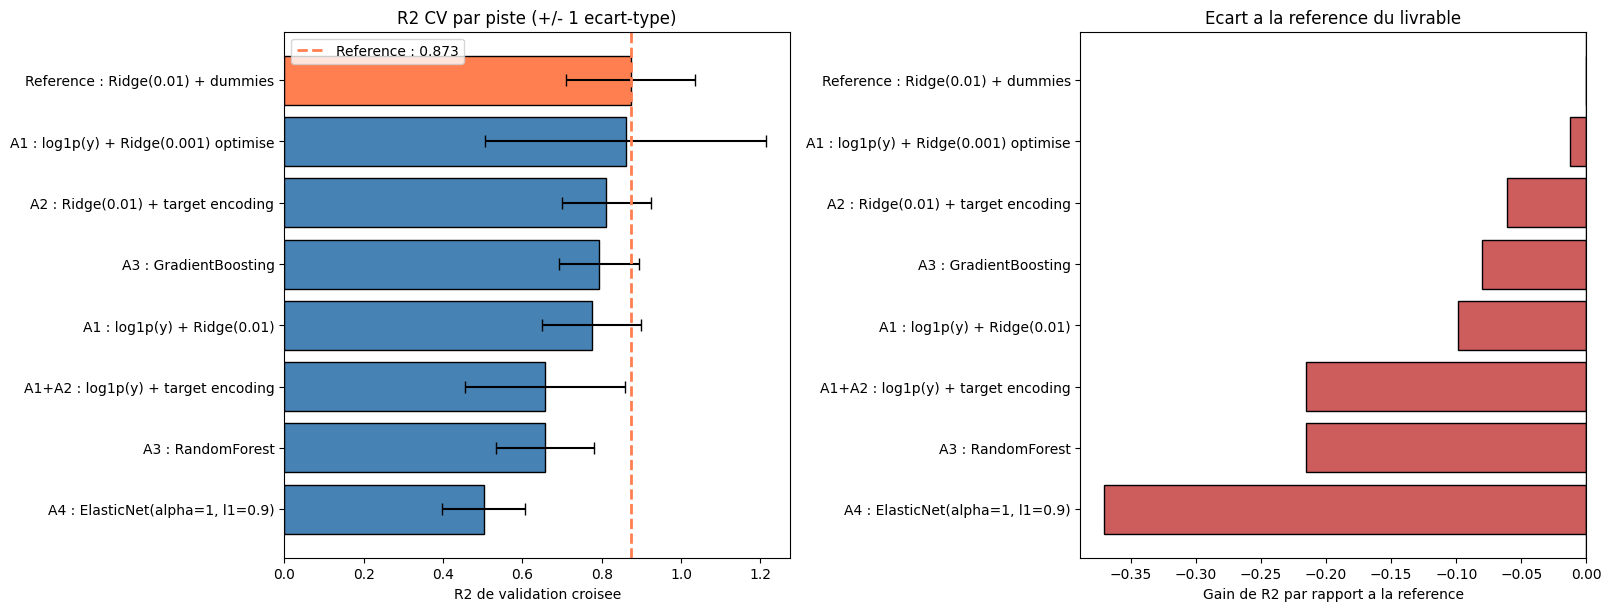

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
ordre = comparaison.iloc[::-1]
couleurs = ['coral' if p.startswith('Reference') else 'steelblue' for p in ordre['Piste']]

axes[0].barh(ordre['Piste'], ordre['R2 CV'], xerr=ordre['Std R2'],
             color=couleurs, edgecolor='black', capsize=4)
axes[0].axvline(ref['R2 CV'], color='coral', linestyle='--', linewidth=2,
                label=f"Reference : {ref['R2 CV']:.3f}")
axes[0].set_xlabel('R2 de validation croisee')
axes[0].set_title('R2 CV par piste (+/- 1 ecart-type)')
axes[0].legend()

axes[1].barh(ordre['Piste'], ordre['Gain R2'],
             color=['seagreen' if g > 0 else 'indianred' for g in ordre['Gain R2']],
             edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Gain de R2 par rapport a la reference')
axes[1].set_title('Ecart a la reference du livrable')

plt.show()

In [11]:
# Chaque piste est-elle reellement differente de la reference, ou est-ce du bruit
# de decoupage ? Sur 90 lignes d'entrainement la question n'est pas rhetorique.
from scipy import stats

ref_nom = ref['Piste']
r2_ref = results[ref_nom]['r2_folds']

lignes = []
for nom, s in results.items():
    if nom == ref_nom:
        continue
    ecart = s['r2_folds'] - r2_ref
    _, p_value = stats.wilcoxon(s['r2_folds'], r2_ref)
    lignes.append({
        'Piste': nom,
        'Gagne': f"{int((ecart > 0).sum())}/{len(ecart)}",
        'Gain median': float(np.median(ecart)),
        'p-value': p_value,
        'Std R2': s['r2_std'],
        'R2 min': s['r2_min'],
    })

apparie = pd.DataFrame(lignes).sort_values('Gain median', ascending=False)

print(f"COMPARAISON APPARIEE CONTRE LA REFERENCE ({ref_nom})")
print(f"Reference : R2 {ref['R2 CV']:.4f} +/- {ref['Std R2']:.4f}, pire fold {ref['R2 min']:.3f}\n")
print(apparie.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

meilleures = apparie[(apparie['Gain median'] > 0) & (apparie['p-value'] < 0.05)]
print()
if len(meilleures):
    print("Pistes significativement MEILLEURES que la reference :")
    for _, r in meilleures.iterrows():
        print(f"  - {r['Piste']} (gain median {r['Gain median']:+.4f}, p = {r['p-value']:.4g})")
else:
    print("AUCUNE piste ne bat significativement la reference sur le R2 moyen.")
    print("Le modele conforme a l'enonce est le meilleur des huit sur ce critere.")

# La moyenne n'est pas le seul critere : la regularite compte aussi.
plus_stables = apparie[apparie['Std R2'] < ref['Std R2']]
if len(plus_stables):
    print("\nPistes PLUS REGULIERES que la reference (ecart-type plus faible) :")
    for _, r in plus_stables.sort_values('Std R2').iterrows():
        print(f"  - {r['Piste']:45s} std {r['Std R2']:.3f} vs {ref['Std R2']:.3f}, "
              f"pire fold {r['R2 min']:+.3f} vs {ref['R2 min']:+.3f}")

COMPARAISON APPARIEE CONTRE LA REFERENCE (Reference : Ridge(0.01) + dummies)
Reference : R2 0.8729 +/- 0.1617, pire fold -0.157

                                Piste Gagne  Gain median  p-value  Std R2  R2 min
A1 : log1p(y) + Ridge(0.001) optimise 41/50       0.0164   0.0000  0.3538 -1.5211
   A2 : Ridge(0.01) + target encoding  7/50      -0.0638   0.0000  0.1132  0.2847
                A3 : GradientBoosting  6/50      -0.0809   0.0000  0.1011  0.4839
          A1 : log1p(y) + Ridge(0.01)  5/50      -0.1037   0.0000  0.1244  0.2394
   A1+A2 : log1p(y) + target encoding  5/50      -0.1827   0.0000  0.2012 -0.0910
                    A3 : RandomForest  2/50      -0.2230   0.0000  0.1240  0.3859
     A4 : ElasticNet(alpha=1, l1=0.9)  2/50      -0.4019   0.0000  0.1045  0.3028

Pistes significativement MEILLEURES que la reference :
  - A1 : log1p(y) + Ridge(0.001) optimise (gain median +0.0164, p = 1.165e-05)

Pistes PLUS REGULIERES que la reference (ecart-type plus faible) :
  - A3 : Gra

## Conclusion

Les trois criteres d'evaluation — moyenne, comparaison appariee, queue de distribution — donnent
**trois classements differents**. C'est le resultat principal de ce notebook, et il n'etait pas
previsible.

### 1. Sur le R2 moyen, la reference conforme a l'enonce gagne

Aucune des huit configurations ne fait mieux que `Ridge(0.01)` + dummies (0.873). Les ecarts
vont de -0.01 pour la transformation log a -0.37 pour ElasticNet. Avec 90 lignes
d'entrainement, tout mecanisme qui contraint davantage le modele perd plus en biais qu'il ne
gagne en variance.

### 2. Sur la comparaison appariee, A1 gagne — mais pour une raison qui doit alerter

`log1p(y) + Ridge(0.001)` **bat la reference sur 41 folds sur 50** (gain median +0.016,
p = 1.2e-05). Sa moyenne est pourtant plus basse (0.860 contre 0.873).

Les deux constats ne se contredisent pas : cette piste est **habituellement meilleure et
occasionnellement catastrophique**. Son pire fold tombe a **-1.52**, contre -0.16 pour la
reference, et son ecart-type double (0.354 contre 0.162). Un seul fold suffit a inverser le
classement des moyennes.

La lecon est methodologique : **comparer deux moyennes ne suffit pas**, et un test apparie seul
ne suffit pas non plus. Il faut regarder les deux, plus la queue de distribution.

### 3. Sur la regularite, cinq pistes sur sept battent la reference

| Piste | Ecart-type | Pire fold |
|---|---|---|
| Reference (enonce) | 0.162 | **-0.157** |
| A3 GradientBoosting | 0.101 | +0.484 |
| A4 ElasticNet | 0.104 | +0.303 |
| A2 target encoding | 0.113 | +0.285 |
| A3 RandomForest | 0.124 | +0.386 |

Toutes sont moins performantes en moyenne, mais **aucune ne produit de prevision aberrante**.
La reference, elle, descend en negatif sur son pire fold.

**A2 gagne en outre la ou elle a ete concue pour gagner** : sur les magasins 11 et 12, presents
dans le hold-out mais absents du train, l'erreur absolue moyenne passe de **660 819 $ a
224 730 $**, soit trois fois moins. Elle ramene par ailleurs 29 features a 12 (ratio p/n de 0.32
a 0.13).

### 4. La vraie limite reste la taille du dataset

Aucune piste ne fait descendre l'ecart-type sous 0.10. Avec 90 lignes d'entrainement pour
20 magasins, l'incertitude est structurelle : elle vient des donnees, pas du modele. Le
bootstrap du livrable le montrait deja — l'intervalle a 95 % du R2 sur le hold-out s'etend de
0.34 a 0.96. **Plus de donnees historiques resserrerait cet intervalle bien plus surement que
n'importe lequel de ces changements de modele.**

### Que retenir

- **Pour le rendu** : la reference, qui est le modele du livrable. Meilleure moyenne, et
  conforme a l'enonce.
- **Pour un usage reel** : `A2` (target encoding), si l'enjeu est de prevoir les ventes de
  magasins recents ou peu representes. Elle sacrifie 0.06 de R2 moyen pour ne jamais s'effondrer
  et pour diviser par trois l'erreur sur les magasins inconnus.
- **A eviter** : `A1` seule. Son gain typique ne compense pas son risque de queue.

---

**Rien de ce notebook n'est reporte dans le livrable**, qui reste strictement conforme a
l'enonce.